In [ ]:
import fiftyone as fo

# 1. Set local paths (Update these to your local paths!)
# On Windows, use raw strings: r"C:\path\to\data"
data_path = r"C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\1st-krones-vision-ai-challenge\train_images"
labels_path = r"C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\1st-krones-vision-ai-challenge\train_annotations.json"
dataset_name = "Krones_Vision_AI_Challenge"

# 2. Import the dataset
# This helper automatically parses COCO formatted annotations
dataset = fo.Dataset.from_dir(
    dataset_type=fo.types.COCODetectionDataset,
    data_path=data_path,
    labels_path=labels_path,
    name=dataset_name,
)

dataset = fo.load_dataset("Krones_Vision_AI_Challenge")

# 3. Launch the app
session = fo.launch_app(dataset)

# # Block execution so the app stays open
session.wait()

# list all datasets in the app
# print("Datasets in FiftyOne App:")
# for ds in fo.list_datasets():
#     print(f"- {ds}")

# fo.delete_dataset("Krones_Vision_AI_Challenge")

Detected circle: Center=(621, 527), Radius=340


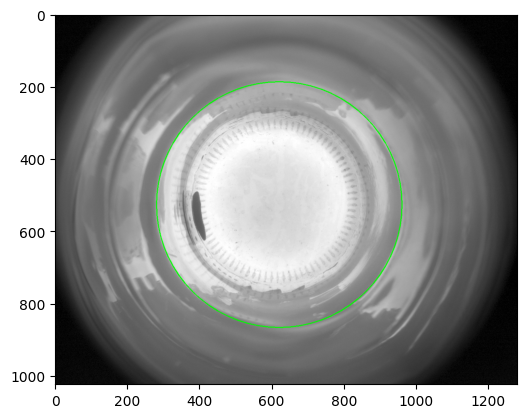

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_hough_transform(image, dp=1.2, min_dist=500, param1=100, param2=40, min_r=300, max_r=600):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp, min_dist,
                               param1=param1, param2=param2,
                               minRadius=min_r, maxRadius=max_r)
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        return circles[0]  # Return the first detected circle (cx, cy, r)
    else:
        print("No circles detected")
        return None

img_path = r"C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\1st-krones-vision-ai-challenge\train_images\fe375934-bb28-4417-860d-de6ab5ba8d5b_000000013483.png"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

circle = apply_hough_transform(img)
if circle is not None:
    cx, cy, r = circle
    cv2.circle(img, (cx, cy), r, (0, 255, 0), 2)
    print(f"Detected circle: Center=({cx}, {cy}), Radius={r}")
else:
    print("No circle detected")


plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()